### Subargument 4: Higher academic performance may go alongside higher stress 

_Despite may affect mental wellbeing, strictly follow intense study schedule brings fruitful result_

In [5]:
# Import
import pandas as pd
import numpy as np
import plotly.graph_objs as go
import plotly.express as px

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [6]:
# Read in
df = pd.read_csv("../../data/student_lifestyle_dataset.csv")

# Remove duplicates


df = df.drop_duplicates()


# Handle missing values


    # Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns
    
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

    # Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='string').columns
    
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# Filter unwanted outliers
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


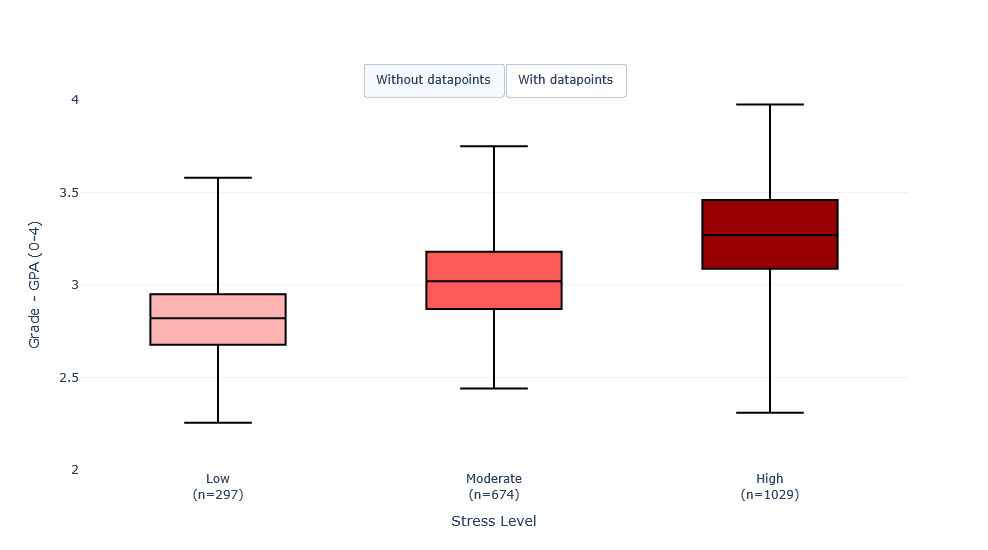

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go


# Ensure consistent stress order
stress_order = ["Low", "Moderate", "High"]
df["Stress_Level"] = pd.Categorical(df["Stress_Level"], categories=stress_order, ordered=True)

# Count students per group, to show sample size transparently
group_counts = df["Stress_Level"].value_counts().reindex(stress_order)
x_labels = {s: f"{s}<br>(n={group_counts[s]})" for s in stress_order}

# Different shades of red, one per stress level
red_shades = {
    "Low": "rgb(255,180,180)",
    "Moderate": "rgb(255,90,90)",
    "High": "rgb(150,0,0)"
}

fig = go.Figure()

# --- Traces 0,1,2: NO-DOTS version (visible by default) ---
for stress in stress_order:
    subset = df[df["Stress_Level"] == stress]
    fig.add_trace(go.Box(
        x=[x_labels[stress]] * len(subset),
        y=subset["GPA"],
        name=stress,
        boxpoints=False,
        line_color="black",
        fillcolor=red_shades[stress],
        marker=dict(color="rgb(80,0,0)"),
        hovertemplate=(
            "Stress Level: " + stress + "<br>"
            "Grade: %{y:.2f}<br>"
            "Group size: n=" + str(group_counts[stress]) + "<extra></extra>"
        ),
        visible=True
    ))

# --- Traces 3,4,5: WITH-DOTS version (hidden by default) ---
for stress in stress_order:
    subset = df[df["Stress_Level"] == stress]
    fig.add_trace(go.Box(
        x=[x_labels[stress]] * len(subset),
        y=subset["GPA"],
        name=stress,
        boxpoints="all",
        jitter=0.4,
        pointpos=0,
        line_color="black",
        fillcolor=red_shades[stress],
        marker=dict(color="rgb(80,0,0)", size=4, opacity=0.5),
        hovertemplate=(
            "Stress Level: " + stress + "<br>"
            "Grade: %{y:.2f}<br>"
            "Group size: n=" + str(group_counts[stress]) + "<extra></extra>"
        ),
        visible=False
    ))

n_groups = len(stress_order)
no_dots_mask = [True] * n_groups + [False] * n_groups
with_dots_mask = [False] * n_groups + [True] * n_groups

fig.update_layout(
    xaxis_title="Stress Level",
    yaxis_title="Grade - GPA (0-4)",
    yaxis=dict(range=[2, 4]),
    showlegend=False,
    height=550,
    width=950,
    template="plotly_white",
    updatemenus=[
        dict(
            type="buttons",
            direction="left",
            x=0.5,
            y=1.1,
            xanchor="center",
            showactive=True,
            buttons=[
                dict(label="Without datapoints", method="update", args=[{"visible": no_dots_mask}]),
                dict(label="With datapoints", method="update", args=[{"visible": with_dots_mask}])
            ]
        )
    ]
)

fig.show(config={"displayModeBar": False})